# Part 4: GRU (Gated Recurrent Unit)

**Owner:** Serein Byiringiro Shima

This notebook trains a regression network, **Embedding → GRU → Dense(1)**, that reads each tweet as a sequence of tokens and predicts its sentiment towards vaccination (-1 negative, 0 neutral, 1 positive). It uses the group's shared train/validation split and is scored by RMSE on the validation tweets, exactly like the other four models.

| Output | Path |
|---|---|
| Validation predictions | `results/gru_validation_predictions.csv` |
| Experiment log (every run) | `results/experiments/gru_experiments.csv` |
| Figures | `results/figures/gru_*.png` |
| Final model | `models/gru.keras` (+ `models/gru_vectorizer.json`) |

## 1. Setup

In [1]:
# Setup: works on Google Colab and locally.
import os
import subprocess
import sys
from pathlib import Path

REPO = "vaccine-sentiment-sequential-models"
if "google.colab" in sys.modules:
    ROOT = Path("/content") / REPO
    if not ROOT.exists():
        subprocess.run(["git", "clone", "--depth", "1",
                        f"https://github.com/Adossi-design/{REPO}.git", str(ROOT)], check=True)
    else:  # already cloned: pull the latest commits
        subprocess.run(["git", "-C", str(ROOT), "pull", "--ff-only"], check=True)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r",
                    str(ROOT / "requirements.txt")], check=True)
else:
    ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "src" / "common.py").exists())
sys.path.insert(0, str(ROOT))
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "3")  # hide TensorFlow's C++ log lines; Python errors still show

from src import common

common.print_environment()
common.set_seed()

Python 3.13.16
numpy 2.5.3
pandas 3.0.6
scikit-learn 1.9.1
tensorflow 2.21.0
keras 3.15.1
GPU none


In [2]:
import json
import time
import warnings

import keras
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf

# Same seed + same hardware type => same numbers. Without this, one GPU kernel used for
# the embedding gradient adds floating-point sums in a random order.
tf.config.experimental.enable_op_determinism()
tf.get_logger().setLevel("ERROR")  # hides the harmless "retracing" warning from predicting with many models

OWNER = "Serein Byiringiro Shima"
MODEL = "gru"
MAX_EPOCHS = 30  # upper bound; early stopping normally ends training much sooner
PATIENCE = 3     # epochs without a better validation loss before stopping
MIN_COUNT = 2    # a word needs this many training occurrences to get its own embedding
LOG_PATH = common.EXPERIMENTS_DIR / f"{MODEL}_experiments.csv"
common.FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Figure style: thin marks, a recessive grid, and two fixed series colours.
INK, INK_2, GRID = "#0b0b0b", "#52514e", "#e4e3df"
BLUE, ORANGE, GRAY = "#2a78d6", "#eb6834", "#8a8984"
plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white", "savefig.facecolor": "white",
    "axes.edgecolor": GRID, "axes.labelcolor": INK_2, "axes.titlecolor": INK,
    "xtick.color": INK_2, "ytick.color": INK_2, "text.color": INK,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 10, "axes.titlesize": 11, "axes.titleweight": "bold",
    "lines.linewidth": 2, "savefig.dpi": 200, "savefig.bbox": "tight",
})

## 2. Text preparation

All five models use the same cleaning, `prepare_series()` from `src/preprocess.py`, which notebook 01 chose from its EDA. Using it here means a difference between the GRU and the other models comes from the model, not from different input tokens. With its default settings it:

- decodes HTML entities (`&amp;` becomes `&`) and straightens curly quotes;
- shortens a letter repeated three or more times to two (`noooo` becomes `noo`), leaving numbers unchanged;
- lowercases the text;
- keeps `<user>` and `<url>` as single tokens, hashtags whole (`#vaccineswork`), contractions together (`isn't`), and `!`, `?`, `…` and each emoji as tokens of their own;
- drops all other punctuation; a tweet with no tokens left becomes `<empty>`.

The cleaned tweet is its tokens joined by single spaces, so `TextVectorization` (Keras Team, n.d.-c) is set to `standardize=None` and `split="whitespace"`. Its default standardization would strip the hashtags, `!`, `?` and emojis that notebook 01 decided to keep, and turn `isn't` into `isnt`.

In [3]:
from src.preprocess import DEFAULT_CONFIG, prepare_series

STANDARDIZE = None    # prepare_series() has already lowercased and tokenized the text
SPLIT = "whitespace"  # its tokens are joined by single spaces
PREPROCESSING = "prepare_series() from src/preprocess.py: the shared cleaning chosen in notebook 01 from the EDA"
print("Cleaning settings:", DEFAULT_CONFIG.describe())


def prepare_text(texts: pd.Series) -> np.ndarray:
    # The group's shared cleaning, so all five models read exactly the same tokens.
    return prepare_series(texts).to_numpy()

Cleaning settings: lowercase=True, hashtags=keep, keep_punct=True, keep_emoji=True, squeeze_elongation=True


## 3. Shared split

`common.load_train_validation()` returns exactly the rows listed in `splits/train_ids.csv` and `splits/validation_ids.csv`, and fails if the files are missing, overlap, or select an invalid label. Nothing in this notebook creates its own split.

A model that ignores the text and always predicts the training mean gives the reference RMSE every model must clearly beat. RMSE squares each error before averaging, so a negative tweet predicted as positive (error 2) costs four times as much as one predicted as neutral (error 1).

In [4]:
train_df, val_df = common.load_train_validation()
train_text, val_text = prepare_text(train_df["safe_text"]), prepare_text(val_df["safe_text"])
y_train = train_df["label"].to_numpy(dtype="float32")
y_val = val_df["label"].to_numpy(dtype="float32")

print(f"{len(train_df):,} training and {len(val_df):,} validation tweets")
display(pd.DataFrame({
    "train share": train_df["label"].value_counts(normalize=True),
    "validation share": val_df["label"].value_counts(normalize=True),
}).sort_index().round(3))

CONSTANT_RMSE = common.rmse(y_val, np.full_like(y_val, y_train.mean()))
print(f"Always predicting the training mean ({y_train.mean():.3f}) gives validation RMSE {CONSTANT_RMSE:.4f}")

8,001 training and 1,999 validation tweets


,train share,validation share
label,,
-1.0,0.104,0.103
0.0,0.491,0.491
1.0,0.405,0.406


Always predicting the training mean (0.301) gives validation RMSE 0.6459


## 4. Vocabulary and sequence length

`TextVectorization` (Keras Team, n.d.-c) turns each tweet into a list of integer token IDs. It is **adapted on the training tweets only**, so no validation text influences the vocabulary or the sequence length.

- **Vocabulary size.** A word seen once in training has a single example to learn its embedding from, so it is mapped to the unknown token `[UNK]` instead. `MAX_TOKENS` keeps every word that occurs at least `MIN_COUNT` times, plus the two reserved IDs (0 = padding, 1 = `[UNK]`).
- **Sequence length.** A GRU trains on batches of equal-length sequences, so every tweet is cut or padded to `MAX_LEN` tokens. Too short loses words at the end of long tweets; too long adds padding and cost for nothing. `MAX_LEN` is the 99th percentile of training token counts, rounded up, so at most 1% of training tweets are truncated (the exact share is printed below). Round 1 tests the 90th percentile and the maximum as alternatives.

In [5]:
# Adapt with no vocabulary limit, then count token frequencies and tweet lengths.
full_vectorizer = keras.layers.TextVectorization(standardize=STANDARDIZE, split=SPLIT)
full_vectorizer.adapt(train_text)
train_ids = full_vectorizer(train_text).numpy()  # padded to the longest training tweet
counts = np.bincount(train_ids.ravel(), minlength=full_vectorizer.vocabulary_size())
lengths = (train_ids != 0).sum(axis=1)

n_words = full_vectorizer.vocabulary_size() - 2   # minus padding and [UNK]
n_kept = int((counts[2:] >= MIN_COUNT).sum())      # the vocabulary is sorted by frequency
MAX_TOKENS = n_kept + 2
print(f"{n_words:,} distinct training tokens; {n_kept:,} occur at least {MIN_COUNT} times, so MAX_TOKENS = {MAX_TOKENS:,}")
print(f"Words below the cut-off are {counts[2 + n_kept:].sum() / counts[2:].sum():.1%} of all training token occurrences")

percentiles = {f"p{q}": int(np.ceil(np.percentile(lengths, q))) for q in (50, 90, 95, 99)}
percentiles["max"] = int(lengths.max())
display(pd.DataFrame([percentiles], index=["tokens per training tweet"]))
MAX_LEN = percentiles["p99"]
print(f"MAX_LEN = {MAX_LEN}; {(lengths > MAX_LEN).mean():.1%} of training tweets are truncated")

12,776 distinct training tokens; 5,664 occur at least 2 times, so MAX_TOKENS = 5,666
Words below the cut-off are 5.3% of all training token occurrences


,p50,p90,p95,p99,max
tokens per training tweet,17,24,25,28,48


MAX_LEN = 28; 0.7% of training tweets are truncated


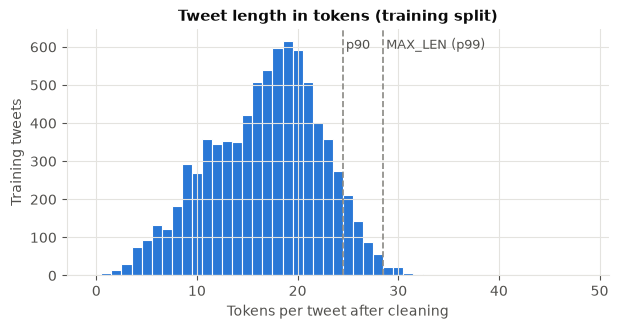

In [6]:
fig, ax = plt.subplots(figsize=(7, 3.2))
ax.hist(lengths, bins=np.arange(lengths.max() + 2) - 0.5, color=BLUE, edgecolor="white", linewidth=0.8)
top = ax.get_ylim()[1]
for name, x in [("p90", percentiles["p90"]), ("MAX_LEN (p99)", MAX_LEN)]:
    ax.axvline(x + 0.5, color=GRAY, linestyle="--", linewidth=1.2)
    ax.text(x + 0.8, top * 0.92, name, color=INK_2, fontsize=9)
ax.set(xlabel="Tokens per tweet after cleaning", ylabel="Training tweets",
       title="Tweet length in tokens (training split)")
fig.savefig(common.FIGURES_DIR / "gru_sequence_lengths.png")
plt.show()

These numbers match notebook 01, which counts the same 5,664 training words seen at least twice, and the Simple RNN and LSTM notebooks, which use the same `MAX_TOKENS` (5,666) and `MAX_LEN` (28), so all three recurrent models read identical token sequences. Notebook 01 suggested `max_len = 32`; round 1 tests 24 (p90) and 48 (no truncation), which bracket it.


### From text to padded token sequences

`TextVectorization` keeps the **first** `MAX_LEN` tokens and pads at the **end**. End padding matters: with `mask_zero=True` the fast cuDNN GRU kernel on a GPU requires it, and stops with an error otherwise. `prepare_series()` never returns an empty string, but as a safeguard a sequence with no tokens is given a single `[UNK]` token, because a fully masked sequence is also rejected by that kernel.

In [7]:
_vectorizers = {}


def get_vectorizer(max_tokens, max_len):
    # TextVectorization adapted on the training tweets only, cached per setting.
    key = (max_tokens, max_len)
    if key not in _vectorizers:
        vectorizer = keras.layers.TextVectorization(
            max_tokens=max_tokens, standardize=STANDARDIZE, split=SPLIT, output_sequence_length=max_len
        )
        vectorizer.adapt(train_text)
        _vectorizers[key] = vectorizer
    return _vectorizers[key]


def to_ids(vectorizer, texts):
    ids = vectorizer(texts).numpy()
    ids[~ids.any(axis=1), 0] = 1  # an empty tweet becomes one [UNK] token
    return ids


vectorizer = get_vectorizer(MAX_TOKENS, MAX_LEN)
raw_val = vectorizer(val_text).numpy()
val_tokens = raw_val[raw_val != 0]
print(f"Tweets with no tokens: {int((lengths == 0).sum())} training, {int((~raw_val.any(axis=1)).sum())} validation")
print(f"{(val_tokens == 1).mean():.1%} of validation tokens are unknown to the vocabulary ([UNK])")

Tweets with no tokens: 0 training, 0 validation
8.2% of validation tokens are unknown to the vocabulary ([UNK])


## 5. The GRU model

**Why a recurrent model.** The TF-IDF baselines see a tweet as a bag of words, so "safe, not risky" and "risky, not safe" get the same features. A recurrent network reads the tokens in order and updates a hidden state after each one, so word order and negation can change what it predicts.

**Why gates.** A simple RNN rewrites its whole hidden state at every step. Learning a link between an early word and the prediction gets harder the further apart they are, because the training signal passed back through many steps tends to vanish or explode (Bengio et al., 1994; Pascanu et al., 2013). The LSTM added multiplicative gates that control what is stored and read (Hochreiter & Schmidhuber, 1997). The GRU (Cho et al., 2014) is a simpler gated unit with two gates:

- the **update gate** $z_t$ decides how much of the previous state is carried over and how much is replaced by a new candidate;
- the **reset gate** $r_t$ decides how much of the previous state is used when that candidate is computed.

$$z_t = \sigma(W_z x_t + U_z h_{t-1} + b_z), \qquad r_t = \sigma(W_r x_t + U_r h_{t-1} + b_r)$$

$$\tilde h_t = \tanh\big(W_h x_t + r_t \odot (U_h h_{t-1}) + b_h\big), \qquad h_t = z_t \odot h_{t-1} + (1 - z_t) \odot \tilde h_t$$

This is the Keras form: its default `reset_after=True`, the cuDNN-compatible variant, applies the reset gate after multiplying by $U_h$ (bias terms simplified here; Keras Team, n.d.-b). When $z_t$ is close to 1 the old state passes through almost unchanged, so information from early words can reach the end of the tweet. Cho et al. (2014) describe units whose reset gates are often active as capturing short-term dependencies, and units whose update gates are mostly active as capturing longer-term ones. The GRU has no separate memory cell or output gate, so it needs three blocks of recurrent weights where the LSTM needs four; section 10 counts them.

**What earlier studies lead us to expect.**

- Chung et al. (2014) compared a tanh RNN, an LSTM and a GRU on music and speech modelling. Both gated units clearly beat the tanh RNN, but the authors could not say whether the GRU or the LSTM is better; it depended on the dataset.
- Jozefowicz et al. (2015) searched about 10,000 recurrent architectures. The GRU beat the standard LSTM on all their tasks except language modelling, although an LSTM with its forget-gate bias set to 1 closed the gap.
- Yin et al. (2017) found a GRU best on binary movie-review sentence sentiment, with its advantage growing with sentence length. On short sentences the GRU and a CNN were comparable, and the CNN did well when one key phrase decides the label.
- On vaccine tweets, Zhang et al. (2020) found that a bidirectional GRU with attention and no pretrained embeddings did not beat a linear SVM on 6,000 HPV-vaccine tweets; pretrained embeddings improved it, and fine-tuned BERT did best.

So the expectation is modest. Tweets are short (section 4) and their sentiment may often hang on a few key words, so the GRU may beat the Simple RNN without beating the TF-IDF baselines. Section 10 and notebook 05, which compares all five approaches, test this.

**Other design choices.**

- `Embedding(..., mask_zero=True)` learns a vector for each vocabulary word; padding (ID 0) is masked, so the GRU skips it.
- One GRU layer returning its final hidden state (a summary of the whole tweet) is a reasonable start for short texts.
- `Dense(1)` with a linear output and mean squared error loss: the target is a score from -1 to 1 treated as regression, as in the challenge's starter notebook, and minimising MSE minimises RMSE.
- Adam (Kingma & Ba, 2015) with its default learning rate of 0.001 as the baseline; round 1 tests 0.0003 and 0.003.
- Dropout (Srivastava et al., 2014) on the GRU's inputs. Gal and Ghahramani (2016) studied dropout in recurrent layers on a model close to this one: an embedding, one LSTM or GRU layer and a scalar output predicting film-review scores. `recurrent_dropout` stays at 0 because any other value switches off the fast cuDNN kernel on a GPU (Keras Team, n.d.-b).
- Early stopping on the validation loss, keeping the weights of the best epoch (Prechelt, 1998; Keras Team, n.d.-a).

In [8]:
def build_gru(vocab_size, embedding_dim, units, dropout, learning_rate):
    model = keras.Sequential(
        [
            keras.Input(shape=(None,), dtype="int64"),
            keras.layers.Embedding(vocab_size, embedding_dim, mask_zero=True),  # ID 0 = padding, ignored
            keras.layers.GRU(units, dropout=dropout),  # input dropout keeps the fast cuDNN kernel
            keras.layers.Dense(1),                      # linear output: a sentiment score
        ],
        name="gru",
    )
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate),
        loss="mse",  # the square of RMSE, so training minimises the challenge metric
        metrics=[keras.metrics.RootMeanSquaredError(name="rmse")],
    )
    return model


BASELINE = {
    "max_len": MAX_LEN,         # p99 of training tweet lengths (section 4)
    "max_tokens": MAX_TOKENS,   # training words seen at least MIN_COUNT times
    "embedding_dim": 64,        # modest: fewer than 10,000 training tweets
    "units": 64,                # size of the GRU hidden state
    "dropout": 0.2,             # dropout on the GRU inputs
    "learning_rate": 1e-3,      # Adam's default step size
    "batch_size": 64,           # kept fixed so runs differ only in the tested setting
}
build_gru(MAX_TOKENS, BASELINE["embedding_dim"], BASELINE["units"], BASELINE["dropout"], BASELINE["learning_rate"]).summary()

Model: "gru"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, None, 64)       │       362,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 64)             │        24,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 387,649 (1.48 MB)

 Trainable params: 387,649 (1.48 MB)

 Non-trainable params: 0 (0.00 B)

## 6. Training and evaluation routine

`run_experiment` trains one configuration, scores it on the validation tweets and immediately writes the run to `results/experiments/gru_experiments.csv` with all its settings. It records the validation RMSE, the best epoch, the training RMSE at that epoch (averaged over the epoch with dropout on, so only a rough guide to overfitting), the parameter count and the training time.

Each run seeds Python, NumPy and Keras first, trains for at most `MAX_EPOCHS` epochs, and stops once validation loss has not improved for `PATIENCE` epochs, keeping the weights from the best epoch.

**What the validation set is used for.** The shared split has no separate test set, so the validation set is also used during training: to decide when to stop, and in section 8 to choose the final configuration. The same tweets then give the reported RMSE. That number is therefore somewhat optimistic; it is not an independent test score. The seed runs in section 8 show how much of any difference is chance.

In [9]:
RESULTS = {}
LOG_PATH.unlink(missing_ok=True)  # the log is rebuilt on every full run; observations live in section 11


def run_experiment(run_id, config, change, seed=common.SEED):
    common.set_seed(seed)
    vectorizer = get_vectorizer(config["max_tokens"], config["max_len"])
    X_train, X_val = to_ids(vectorizer, train_text), to_ids(vectorizer, val_text)
    model = build_gru(vectorizer.vocabulary_size(), config["embedding_dim"], config["units"],
                      config["dropout"], config["learning_rate"])
    stop = keras.callbacks.EarlyStopping(monitor="val_loss", patience=PATIENCE, restore_best_weights=True)
    start = time.perf_counter()
    history = model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=MAX_EPOCHS,
                        batch_size=config["batch_size"], callbacks=[stop], verbose=0).history
    seconds = time.perf_counter() - start
    pred = model.predict(X_val, batch_size=512, verbose=0).ravel()
    best = int(np.argmin(history["val_loss"]))
    RESULTS[run_id] = r = {
        "config": dict(config), "seed": seed, "change": change,
        "val_rmse": common.rmse(y_val, pred), "best_epoch": best + 1, "epochs_run": len(history["loss"]),
        "train_rmse": float(history["rmse"][best]), "params": model.count_params(), "seconds": round(seconds, 1),
        "history": history, "model": model, "vectorizer": vectorizer, "pred": pred,
    }
    common.log_experiment(
        run_id=run_id,
        owner=OWNER,
        model=MODEL,
        approach="Embedding -> GRU -> Dense(1) with linear output (Keras)",
        input_representation=(f"TextVectorization token IDs (no standardization, split on whitespace): "
                              f"vocabulary {config['max_tokens']}, "
                              f"max_len {config['max_len']}, end-padded and masked"),
        preprocessing=PREPROCESSING,
        hyperparameters={
            **config, "seed": seed, "standardize": "none (prepare_series already cleans the text)",
            "split": SPLIT, "min_count": MIN_COUNT,
            "optimizer": "adam", "loss": "mse", "max_epochs": MAX_EPOCHS,
            "early_stopping": f"val_loss on the shared validation set, patience {PATIENCE}, best weights restored",
            "best_epoch": r["best_epoch"], "epochs_run": r["epochs_run"],
            "train_rmse_at_best_epoch": round(r["train_rmse"], 4), "train_seconds": r["seconds"],
            "params": r["params"],
        },
        change_from_previous=change,
        val_rmse=r["val_rmse"],
        observation="",
    )
    print(f"{run_id}: validation RMSE {r['val_rmse']:.4f} | best epoch {r['best_epoch']} of {r['epochs_run']} | "
          f"train RMSE {r['train_rmse']:.4f} | {r['params']:,} parameters | {r['seconds']}s")
    return r


def results_table(run_ids):
    shown = ["max_len", "embedding_dim", "units", "dropout", "learning_rate"]
    return pd.DataFrame([
        {"run": run_id, **{k: RESULTS[run_id]["config"][k] for k in shown}, "seed": RESULTS[run_id]["seed"],
         "val_rmse": round(RESULTS[run_id]["val_rmse"], 4), "train_rmse": round(RESULTS[run_id]["train_rmse"], 4),
         "best_epoch": RESULTS[run_id]["best_epoch"], "params": RESULTS[run_id]["params"],
         "seconds": RESULTS[run_id]["seconds"]}
        for run_id in run_ids
    ]).set_index("run")

## 7. Round 1: one change at a time

The baseline is trained first. Every other round-1 run changes **one** setting from the baseline, to roughly half and double its value (or a lower and a higher alternative), for the reason written next to it. Only one setting changes, but the training run also changes, so a difference in validation RMSE mixes the effect of the setting with run-to-run noise; section 8 measures that noise before any difference is interpreted. One-at-a-time runs also cannot show how settings interact.

In [10]:
ROUND_1 = [
    ("gru-01", {}, "Baseline: the settings in section 5."),
    ("gru-02", {"max_len": percentiles["p90"]}, "Shorter sequences (p90): do the last words of the longest tweets matter?"),
    ("gru-03", {"max_len": percentiles["max"]}, "No truncation (longest training tweet): does keeping every token help?"),
    ("gru-04", {"embedding_dim": 32}, "Smaller word vectors: less capacity and less room to overfit a small training set."),
    ("gru-05", {"embedding_dim": 128}, "Larger word vectors: do richer word representations help?"),
    ("gru-06", {"units": 32}, "Smaller hidden state: is 64 units more memory than short tweets need?"),
    ("gru-07", {"units": 128}, "Larger hidden state: does more capacity to carry context help?"),
    ("gru-08", {"dropout": 0.0}, "No dropout: is extra regularisation needed when early stopping is used?"),
    ("gru-09", {"dropout": 0.4}, "Stronger dropout: does more regularisation reduce overfitting?"),
    ("gru-10", {"learning_rate": 3e-4}, "Lower learning rate: slower but steadier optimisation."),
    ("gru-11", {"learning_rate": 3e-3}, "Higher learning rate: faster convergence, with a risk of overshooting."),
]
for run_id, change, why in ROUND_1:
    run_experiment(run_id, {**BASELINE, **change}, why)

round_1 = results_table([run_id for run_id, _, _ in ROUND_1])
round_1["vs_baseline"] = (round_1["val_rmse"] - RESULTS["gru-01"]["val_rmse"]).round(4)
display(round_1)

gru-01: validation RMSE 0.5844 | best epoch 2 of 5 | train RMSE 0.5393 | 387,649 parameters | 9.7s


gru-02: validation RMSE 0.5840 | best epoch 2 of 5 | train RMSE 0.5393 | 387,649 parameters | 8.7s


gru-03: validation RMSE 0.5854 | best epoch 2 of 5 | train RMSE 0.5391 | 387,649 parameters | 14.7s


gru-04: validation RMSE 0.5887 | best epoch 2 of 5 | train RMSE 0.5525 | 200,193 parameters | 9.0s


gru-05: validation RMSE 0.5861 | best epoch 2 of 5 | train RMSE 0.5304 | 762,561 parameters | 12.9s


...

gru-08: validation RMSE 0.5905 | best epoch 2 of 5 | train RMSE 0.5333 | 387,649 parameters | 9.5s


gru-09: validation RMSE 0.5769 | best epoch 2 of 5 | train RMSE 0.5508 | 387,649 parameters | 9.9s


gru-10: validation RMSE 0.5788 | best epoch 3 of 6 | train RMSE 0.5311 | 387,649 parameters | 11.6s


gru-11: validation RMSE 0.5839 | best epoch 1 of 4 | train RMSE 0.6099 | 387,649 parameters | 8.1s


,max_len,embedding_dim,units,dropout,learning_rate,seed,val_rmse,train_rmse,best_epoch,params,seconds,vs_baseline
run,,,,,,,,,,,,
gru-01,28,64,64,0.2,0.0010,42,0.5844,0.5393,2,387649,9.7,0.0000
gru-02,24,64,64,0.2,0.0010,42,0.5840,0.5393,2,387649,8.7,-0.0004
gru-03,48,64,64,0.2,0.0010,42,0.5854,0.5391,2,387649,14.7,0.0010
gru-04,28,32,64,0.2,0.0010,42,0.5887,0.5525,2,200193,9.0,0.0043
gru-05,28,128,64,0.2,0.0010,42,0.5861,0.5304,2,762561,12.9,0.0017
gru-06,28,64,32,0.2,0.0010,42,0.5866,0.5449,2,372065,7.3,0.0022
gru-07,28,64,128,0.2,0.0010,42,0.5871,0.5349,2,437249,17.9,0.0027
gru-08,28,64,64,0.0,0.0010,42,0.5905,0.5333,2,387649,9.5,0.0061
gru-09,28,64,64,0.4,0.0010,42,0.5769,0.5508,2,387649,9.9,-0.0075


## 8. Round 2: measure the noise, combine what beat it, choose the final model

Round 2 is decided by round 1's results, in four steps.

1. **How large is run-to-run noise?** gru-12 and gru-13 retrain the baseline with seeds 43 and 44. A different seed changes the initial weights and the order of the batches, so the spread of gru-01, gru-12 and gru-13 shows how much validation RMSE moves by chance; for recurrent networks this can be large enough to flip single-run comparisons (Reimers & Gurevych, 2017). Two single runs of the same configuration typically differ by about √2 times that standard deviation; this is `NOISE`. With three seeds it is only a rough estimate.
2. **Combine the changes that beat the noise.** gru-14 applies, together, every round-1 change that improved on the baseline by more than `NOISE`. If fewer than two did, there is nothing new to combine and gru-14 is skipped.
3. **Choose the final configuration.** Among gru-01 to gru-11 (and gru-14), every run within `NOISE` of the lowest validation RMSE counts as equally good, and the one with the fewest parameters is chosen (ties go to the lower RMSE). This is the idea behind the one-standard-error rule (Hastie et al., 2009): prefer the simplest model whose score cannot be told apart from the best.
4. **Judge it on fresh seeds.** gru-15 and gru-16 retrain the final configuration with seeds 43 and 44. The seed-42 run was chosen because it scored well, so the three-seed mean, and above all the two fresh seeds, are the fairer estimate.

In [11]:
run_experiment("gru-12", BASELINE, "Noise check: the baseline with seed 43.", seed=43)
run_experiment("gru-13", BASELINE, "Noise check: the baseline with seed 44.", seed=44)
BASELINE_RUNS = ["gru-01", "gru-12", "gru-13"]
base_scores = pd.Series({r: RESULTS[r]["val_rmse"] for r in BASELINE_RUNS})
NOISE = float(np.sqrt(2) * base_scores.std())
print(f"Baseline over 3 seeds: mean {base_scores.mean():.4f}, sd {base_scores.std():.4f}, so NOISE = {NOISE:.4f}")

gru-12: validation RMSE 0.5744 | best epoch 2 of 5 | train RMSE 0.5348 | 387,649 parameters | 9.7s


gru-13: validation RMSE 0.5813 | best epoch 2 of 5 | train RMSE 0.5382 | 387,649 parameters | 9.6s
Baseline over 3 seeds: mean 0.5800, sd 0.0051, so NOISE = 0.0072


In [12]:
FACTORS = {
    "max_len": ["gru-02", "gru-03"], "embedding_dim": ["gru-04", "gru-05"], "units": ["gru-06", "gru-07"],
    "dropout": ["gru-08", "gru-09"], "learning_rate": ["gru-10", "gru-11"],
}
base_rmse = RESULTS["gru-01"]["val_rmse"]
combined, adopted = dict(BASELINE), []
for factor, run_ids in FACTORS.items():
    best_id = min(run_ids, key=lambda run_id: RESULTS[run_id]["val_rmse"])
    if base_rmse - RESULTS[best_id]["val_rmse"] > NOISE:
        combined[factor] = RESULTS[best_id]["config"][factor]
        adopted.append(f"{factor} {combined[factor]:g} ({best_id})")
print("Round-1 changes that beat the noise:", ", ".join(adopted) if adopted else "none")

CANDIDATES = [run_id for run_id, _, _ in ROUND_1]
if len(adopted) >= 2:
    run_experiment("gru-14", combined, "Combines the round-1 changes that beat NOISE: " + ", ".join(adopted) + ".")
    CANDIDATES.append("gru-14")
else:
    print("gru-14 skipped: fewer than two changes beat the noise, so there is nothing new to combine.")

best_score = min(RESULTS[r]["val_rmse"] for r in CANDIDATES)
near_best = [r for r in CANDIDATES if RESULTS[r]["val_rmse"] <= best_score + NOISE]
FINAL_RUN = min(near_best, key=lambda r: (RESULTS[r]["params"], RESULTS[r]["val_rmse"]))
FINAL = RESULTS[FINAL_RUN]["config"]
print(f"Runs within NOISE of the best ({best_score:.4f}):")
display(results_table(near_best).sort_values(["params", "val_rmse"]))
print(f"Final configuration: {FINAL_RUN} (fewest parameters among them)")

Round-1 changes that beat the noise: dropout 0.4 (gru-09)
gru-14 skipped: fewer than two changes beat the noise, so there is nothing new to combine.
Runs within NOISE of the best (0.5769):


,max_len,embedding_dim,units,dropout,learning_rate,seed,val_rmse,train_rmse,best_epoch,params,seconds
run,,,,,,,,,,,
gru-09,28,64,64,0.4,0.0010,42,0.5769,0.5508,2,387649,9.9
gru-10,28,64,64,0.2,0.0003,42,0.5788,0.5311,3,387649,11.6
gru-11,28,64,64,0.2,0.0030,42,0.5839,0.6099,1,387649,8.1
gru-02,24,64,64,0.2,0.0010,42,0.5840,0.5393,2,387649,8.7


Final configuration: gru-09 (fewest parameters among them)


In [13]:
if FINAL == BASELINE:
    FINAL_RUNS = BASELINE_RUNS
    print("The final configuration is the baseline, so gru-12 and gru-13 are already its fresh-seed runs.")
else:
    run_experiment("gru-15", FINAL, f"Seed check: the final configuration ({FINAL_RUN}) with seed 43.", seed=43)
    run_experiment("gru-16", FINAL, f"Seed check: the final configuration ({FINAL_RUN}) with seed 44.", seed=44)
    FINAL_RUNS = [FINAL_RUN, "gru-15", "gru-16"]

seed_table = pd.DataFrame({
    "seed": [RESULTS[r]["seed"] for r in BASELINE_RUNS],
    "baseline": [RESULTS[r]["val_rmse"] for r in BASELINE_RUNS],
    "final": [RESULTS[r]["val_rmse"] for r in FINAL_RUNS],
}).set_index("seed")
seed_table["final minus baseline"] = seed_table["final"] - seed_table["baseline"]
display(seed_table.round(4))
FINAL_MEAN, FINAL_SD = seed_table["final"].mean(), seed_table["final"].std()
print(f"Final configuration over 3 seeds: {FINAL_MEAN:.4f} ± {FINAL_SD:.4f} "
      "(the seed-42 run was selected for scoring well, so it is the optimistic one)")
print(f"Fresh seeds only (43 and 44): final {seed_table['final'].iloc[1:].mean():.4f}, "
      f"baseline {seed_table['baseline'].iloc[1:].mean():.4f}")

gru-15: validation RMSE 0.5731 | best epoch 2 of 5 | train RMSE 0.5441 | 387,649 parameters | 9.9s


gru-16: validation RMSE 0.5785 | best epoch 2 of 5 | train RMSE 0.5476 | 387,649 parameters | 10.0s


,baseline,final,final minus baseline
seed,,,
42,0.5844,0.5769,-0.0075
43,0.5744,0.5731,-0.0014
44,0.5813,0.5785,-0.0028


Final configuration over 3 seeds: 0.5762 ± 0.0028 (the seed-42 run was selected for scoring well, so it is the optimistic one)
Fresh seeds only (43 and 44): final 0.5758, baseline 0.5779


**Reading round 2.** Dropout 0.4 (gru-09) is the only round-1 change that cleared `NOISE`, and only just (0.0075 against 0.0072). That margin is measured against the seed-42 baseline, the worst of its three seeds (0.5844, against 0.5744 and 0.5813); against the three-seed baseline mean (0.5800) the gain is 0.0031, inside `NOISE`. The fresh seeds agree: dropout 0.4 is better on every seed, but by 0.0014 and 0.0028 rather than 0.0075. So stronger dropout is a small, consistent improvement rather than a clear one, and the three-seed mean (0.5762) is the fairer figure to compare with the other models.

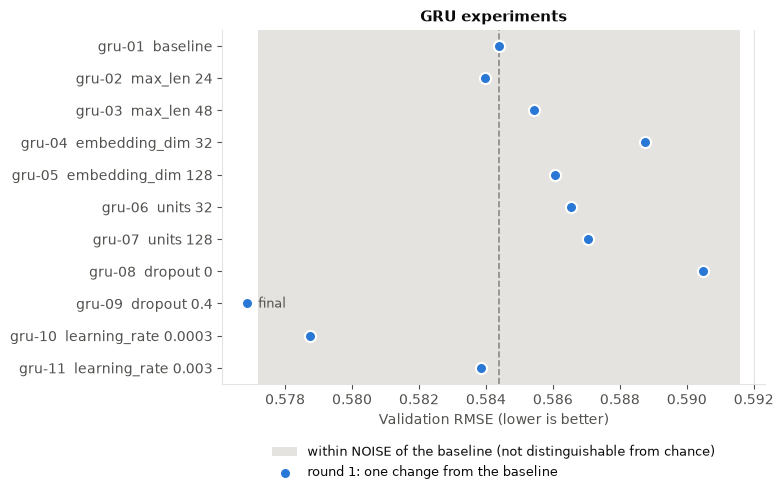

In [14]:
def run_label(run_id, change):
    return f"{run_id}  " + (", ".join(f"{k} {v:g}" for k, v in change.items()) or "baseline")


points = [(r, run_label(r, c), BLUE) for r, c, _ in ROUND_1]
if "gru-14" in RESULTS:
    points.append(("gru-14", "gru-14  combined", ORANGE))
y = np.arange(len(points))[::-1]

fig, ax = plt.subplots(figsize=(7, 4.6))
ax.axvspan(base_rmse - NOISE, base_rmse + NOISE, color=GRID, linewidth=0,
           label="within NOISE of the baseline (not distinguishable from chance)")
ax.axvline(base_rmse, color=GRAY, linestyle="--", linewidth=1.2)
for colour, name in [(BLUE, "round 1: one change from the baseline"), (ORANGE, "round 2: combined")]:
    sel = [i for i, p in enumerate(points) if p[2] == colour]
    if sel:
        ax.scatter([RESULTS[points[i][0]]["val_rmse"] for i in sel], y[sel], color=colour, s=64, zorder=3,
                   edgecolors="white", linewidths=1.5, label=name)
final_i = next((i for i, p in enumerate(points) if p[0] == FINAL_RUN), None)
if final_i is not None:
    ax.annotate("final", (RESULTS[FINAL_RUN]["val_rmse"], y[final_i]), xytext=(8, -3),
                textcoords="offset points", color=INK_2, fontsize=9)
ax.set_yticks(y, [p[1] for p in points])
ax.grid(axis="y", visible=False)
ax.set(xlabel="Validation RMSE (lower is better)", title="GRU experiments")
ax.legend(frameon=False, loc="upper center", bbox_to_anchor=(0.5, -0.14), ncol=1, fontsize=9)
fig.savefig(common.FIGURES_DIR / "gru_experiments.png")
plt.show()

## 9. Final model: learning curve, predictions and saved files

The saved predictions and model come from the final configuration's seed-42 run. The learning curve plots its RMSE per epoch: validation RMSE levelling off or rising while training RMSE keeps falling is the usual sign of overfitting, and the dashed line marks the epoch whose weights early stopping kept.

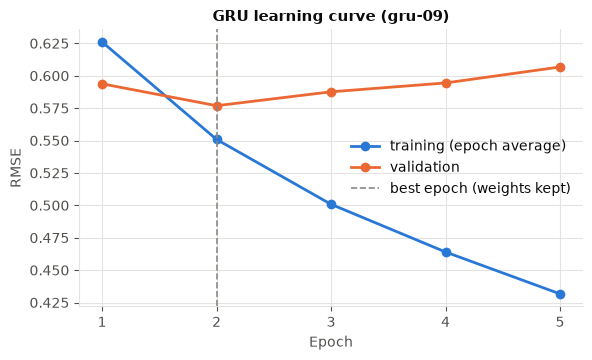

In [15]:
final = RESULTS[FINAL_RUN]
history = final["history"]
epochs = np.arange(1, len(history["loss"]) + 1)

fig, ax = plt.subplots(figsize=(6.5, 3.6))
ax.plot(epochs, history["rmse"], color=BLUE, marker="o", markersize=6, label="training (epoch average)")
ax.plot(epochs, np.sqrt(history["val_loss"]), color=ORANGE, marker="o", markersize=6, label="validation")
ax.axvline(final["best_epoch"], color=GRAY, linestyle="--", linewidth=1.2, label="best epoch (weights kept)")
ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
ax.set(xlabel="Epoch", ylabel="RMSE", title=f"GRU learning curve ({FINAL_RUN})")
ax.legend(frameon=False)
fig.savefig(common.FIGURES_DIR / "gru_learning_curve.png")
plt.show()

In [16]:
common.save_predictions(MODEL, val_df, final["pred"])

# The vocabulary is not saved: it is derived from the tweets, and adapting on the
# training split with these settings rebuilds it exactly.
common.MODELS_DIR.mkdir(parents=True, exist_ok=True)
final["model"].save(common.MODELS_DIR / "gru.keras")
(common.MODELS_DIR / "gru_vectorizer.json").write_text(json.dumps({
    "standardize": "none (prepare_series already cleans the text)", "split": SPLIT,
    "max_tokens": FINAL["max_tokens"], "max_len": FINAL["max_len"],
    "adapted_on": "shared training split (splits/train_ids.csv)", "preprocessing": PREPROCESSING,
}, indent=2))
print("Saved models/gru.keras and models/gru_vectorizer.json")

Saved results/gru_validation_predictions.csv (validation RMSE 0.5769)
Saved models/gru.keras and models/gru_vectorizer.json


### Where the GRU goes wrong

The errors are summarised by true label first: with a regression model and an imbalanced label distribution, predictions for the rarer classes are often pulled towards the overall mean. Then the largest individual errors are listed by `tweet_id`. Tweet text is never saved, in a file or in this notebook's outputs, because the challenge rules do not allow the tweets to be published (Zindi, 2020); the descriptions below come from reading the tweets locally.

,tweets,mean_prediction,rmse
label,,,
-1.0,206,0.209,1.261
0.0,982,0.231,0.329
1.0,811,0.539,0.534


Validation MAE 0.4436 (RMSE 0.5769); 8.8% of validation tweets are off by more than one class step


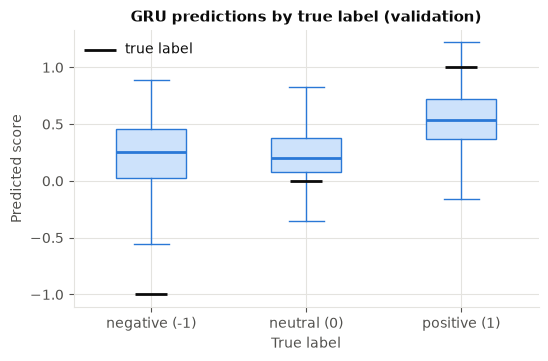

In [17]:
errors = val_df[["tweet_id", "safe_text", "label"]].assign(predicted=final["pred"])
errors["abs_error"] = (errors["predicted"] - errors["label"]).abs()

display(errors.groupby("label").agg(
    tweets=("tweet_id", "size"),
    mean_prediction=("predicted", "mean"),
    rmse=("abs_error", lambda e: float(np.sqrt(np.mean(e ** 2)))),
).round(3))
print(f"Validation MAE {errors['abs_error'].mean():.4f} (RMSE {common.rmse(errors['label'], errors['predicted']):.4f}); "
      f"{(errors['abs_error'] > 1).mean():.1%} of validation tweets are off by more than one class step")

fig, ax = plt.subplots(figsize=(6, 3.6))
ax.boxplot([errors.loc[errors["label"] == k, "predicted"] for k in (-1, 0, 1)], positions=[-1, 0, 1],
           widths=0.45, patch_artist=True, showfliers=False,
           boxprops={"facecolor": "#cde2fb", "edgecolor": BLUE}, medianprops={"color": BLUE, "linewidth": 2},
           whiskerprops={"color": BLUE}, capprops={"color": BLUE})
ax.scatter([-1, 0, 1], [-1, 0, 1], marker="_", s=500, linewidths=2, color=INK, zorder=3, label="true label")
ax.set_xticks([-1, 0, 1], ["negative (-1)", "neutral (0)", "positive (1)"])
ax.set(xlabel="True label", ylabel="Predicted score", title="GRU predictions by true label (validation)")
ax.legend(frameon=False, loc="upper left")
fig.savefig(common.FIGURES_DIR / "gru_predictions_by_label.png")
plt.show()

In [18]:
NEGATION = r"\b(?:not|no|never|nor|cannot)\b|n['’]t"  # notebook 03's word list; n['’]t also catches curly apostrophes
display(errors.nlargest(15, "abs_error")[["tweet_id", "label", "predicted", "abs_error"]].round(3))  # IDs only, no tweet text

# Agreement is used only to describe errors, never as a model input.
top15 = errors.nlargest(15, "abs_error").assign(
    negation=lambda d: d["safe_text"].str.lower().str.contains(NEGATION, regex=True),
    agreement=lambda d: d["tweet_id"].map(val_df.set_index("tweet_id")["agreement"]),
)
negatives = val_df["label"] == -1
print(f"15 largest errors: {(top15['label'] == -1).sum()} negative tweets, {top15['negation'].sum()} with a negation, "
      f"lowest prediction {top15['predicted'].min():.3f}")
print(f"Mean agreement: 15 largest errors {top15['agreement'].mean():.2f} ({(top15['agreement'] == 1).sum()} with full agreement), "
      f"all negative validation tweets {val_df.loc[negatives, 'agreement'].mean():.2f}")
print(f"Negative validation tweets predicted below -0.5: {(errors.loc[negatives.to_numpy(), 'predicted'] < -0.5).sum()} of {negatives.sum()}")

,tweet_id,label,predicted,abs_error
287,4M3ND9L9,-1.0,0.891,1.891
637,AP8D8KXB,-1.0,0.844,1.844
1889,XRTV4HU8,-1.0,0.825,1.825
594,A3W81QVQ,-1.0,0.802,1.802
105,1KAVNQ0L,-1.0,0.794,1.794
1460,QK5Y1ZWX,-1.0,0.791,1.791
313,4Y75EP2E,-1.0,0.763,1.763
796,DVMK1WEI,-1.0,0.739,1.739
344,5KDOWBMS,-1.0,0.736,1.736
753,CLK1QITW,-1.0,0.724,1.724


15 largest errors: 15 negative tweets, 8 with a negation, lowest prediction 0.669
Mean agreement: 15 largest errors 0.62 (4 with full agreement), all negative validation tweets 0.71
Negative validation tweets predicted below -0.5: 8 of 206


**What the largest errors have in common.** Every one of the 15 largest errors is a negative tweet predicted as clearly positive (the lowest prediction is 0.669), and only 8 of the 206 negative validation tweets are predicted below -0.5. The by-label table shows the same pull: the mean prediction for negative tweets is 0.209, on the positive side of zero. Reading these 15 tweets locally, four patterns repeat:

- **Negation of a pro-vaccine phrase** (8 of the 15): a reply telling parents not to vaccinate their children (5KDOWBMS) uses the same words as a pro-vaccine tweet, and the GRU appears to weigh them more than the negation.
- **Sarcasm**: the largest error (4M3ND9L9) labels itself as sarcasm, which a model trained on 8,001 tweets has no way to read.
- **Claims that need world knowledge**: tweets saying vaccines caused autism often contain no clearly negative word; the stance lies in the claim.
- **Reported anti-vaccine views**: headlines about anti-vaccine parents are labelled negative although their wording reports rather than argues, so some labels are debatable.

Label noise explains part of this but not all of it: the 15 tweets have a mean annotator agreement of 0.62, below the 0.71 of all negative validation tweets, yet 4 of them have full agreement.


## 10. GRU vs Simple RNN and LSTM

The three recurrent models are trained and scored on the same shared split and differ mainly in how the recurrent layer updates its state: no gates (Simple RNN), two gates (GRU), or three gates plus a separate memory cell (the LSTM in its modern form with a forget gate; Gers et al., 2000). Each owner tunes their own settings, so a difference in RMSE reflects both the architecture and the tuning; notebook 05 compares the final models of all five approaches on the same tweets.

The literature gives no fixed ranking to expect. Gated units beat the tanh RNN in Chung et al. (2014), but GRU versus LSTM depended on the task. For tweet sentiment, Baziotis et al. (2017) chose an LSTM because it did slightly better than a GRU in their experiments.

The first table counts parameters at the final GRU's embedding size and number of units. The embedding dominates the total, but the recurrent layers themselves differ clearly. The second table compares the GRU's validation RMSE with the constant baseline (section 3), the Simple RNN and LSTM (notebooks 02 and 03) and, for context, the two TF-IDF baselines (notebook 01), all read from their saved prediction files; the GRU appears both as the saved single run and as the final configuration's three-seed mean and standard deviation.

The third table asks whether gating helps where word order should matter. It splits the validation tweets by true label and by whether they contain a negation, using the same pattern as notebook 03, and scores the three recurrent models on exactly the same tweets. The last line counts how many of each pair's 50 largest errors are the same tweets.

In [19]:
def count_params(recurrent_layer):
    model = keras.Sequential([
        keras.Input(shape=(None,), dtype="int64"),
        keras.layers.Embedding(FINAL["max_tokens"], FINAL["embedding_dim"], mask_zero=True),
        recurrent_layer,
        keras.layers.Dense(1),
    ])
    return {"recurrent layer": recurrent_layer.count_params(), "whole model": model.count_params()}


units = FINAL["units"]
display(pd.DataFrame({
    "Simple RNN": count_params(keras.layers.SimpleRNN(units)),
    "GRU": count_params(keras.layers.GRU(units)),
    "LSTM": count_params(keras.layers.LSTM(units)),
}).T.rename_axis(f"embedding {FINAL['embedding_dim']}, {units} units"))

comparison = {
    "Constant (training mean)": (CONSTANT_RMSE, np.nan),
    f"GRU, saved run ({FINAL_RUN})": (common.rmse(y_val, final["pred"]), np.nan),
    "GRU, final configuration, 3 seeds": (FINAL_MEAN, FINAL_SD),
}
OTHER_MODELS = [("Simple RNN", "rnn", "02"), ("LSTM", "lstm", "03"),
                ("TF-IDF + Ridge", "ridge", "01"), ("TF-IDF + SVR", "svr", "01")]
other_preds = {}
for name, key, notebook in OTHER_MODELS:
    path = common.RESULTS_DIR / f"{key}_validation_predictions.csv"
    if not path.exists():
        print(f"{path.name} is not available yet (notebook {notebook})")
        continue
    other = pd.read_csv(path, dtype={"tweet_id": str})
    if set(other["tweet_id"]) != set(val_df["tweet_id"]):
        raise ValueError(f"{path.name} does not cover the shared validation tweets")
    comparison[name] = (common.rmse(other["true_label"], other["predicted_label"]), np.nan)
    other_preds[key] = other.set_index("tweet_id")["predicted_label"]
display(pd.DataFrame(comparison, index=["validation RMSE", "sd over seeds"]).T.round(4))

,recurrent layer,whole model
"embedding 64, 64 units",,
Simple RNN,8256,370945
GRU,24960,387649
LSTM,33024,395713


,validation RMSE,sd over seeds
Constant (training mean),0.6459,NaN
"GRU, saved run (gru-09)",0.5769,NaN
"GRU, final configuration, 3 seeds",0.5762,0.0028
Simple RNN,0.5855,NaN
LSTM,0.5780,NaN
TF-IDF + Ridge,0.5628,NaN
TF-IDF + SVR,0.5740,NaN


In [20]:
# Same tweets, three recurrent models: RMSE by true label and by whether the tweet contains a negation.
same = val_df[["tweet_id", "safe_text", "label"]].assign(gru=final["pred"])
recurrent = ["gru"] + [k for k in ("rnn", "lstm") if k in other_preds]
for key in recurrent[1:]:
    same[key] = same["tweet_id"].map(other_preds[key])
same["negation"] = same["safe_text"].str.lower().str.contains(NEGATION, regex=True)
print(f"{same['negation'].mean():.1%} of validation tweets contain a negation")

rows = [{"label": label, "negation": negation, "tweets": len(g),
         **{f"{k}_rmse": common.rmse(g["label"], g[k]) for k in recurrent}}
        for (label, negation), g in same.groupby(["label", "negation"])]
display(pd.DataFrame(rows).set_index(["label", "negation"]).round(4))

top50 = {k: set(same.assign(err=(same[k] - same["label"]).abs()).nlargest(50, "err")["tweet_id"]) for k in recurrent}
pairs = [(a, b) for i, a in enumerate(recurrent) for b in recurrent[i + 1:]]
print("Shared tweets among the 50 largest errors: " + ", ".join(f"{a}/{b} {len(top50[a] & top50[b])}" for a, b in pairs)
      + (f", all three {len(set.intersection(*top50.values()))}" if len(recurrent) == 3 else ""))

25.6% of validation tweets contain a negation


tweets  gru_rmse  rnn_rmse  lstm_rmse
label negation                                       
-1.0  False        146    1.2299    1.2716     1.2753
      True          60    1.3321    1.4405     1.4063
 0.0  False        810    0.3140    0.2907     0.3136
      True         172    0.3917    0.3681     0.4143
 1.0  False        531    0.5565    0.5714     0.5293
      True         280    0.4899    0.4608     0.4383

Shared tweets among the 50 largest errors: gru/rnn 33, gru/lstm 45, rnn/lstm 35, all three 32


### Does gating help on this dataset?

**A little over the Simple RNN, nothing over the LSTM, and less than the word-pair baseline.**

- **GRU vs Simple RNN.** The GRU's saved run (0.5769) is 0.0086 below the Simple RNN (0.5855), slightly more than the GRU's own `NOISE` (0.0072), and its three-seed mean (0.5762) is lower still. The gates give a small gain just beyond chance, although each model was tuned by a different owner.
- **GRU vs LSTM.** 0.5769 against 0.5780 is no difference. The GRU gets there with 24,960 recurrent weights against the LSTM's 33,024, about a quarter fewer, because it has three blocks of recurrent weights where the LSTM has four (section 5).
- **Where the gain comes from.** On negative tweets the GRU's RMSE is lower than both other models, with or without a negation (1.2299 and 1.3321 against 1.27 to 1.44). On neutral tweets it is worse than the Simple RNN, and on positive tweets the LSTM is best. Its advantage is spread over negative tweets with and without a negation, so it does not come from handling negation specifically. The negated negative group has only 60 tweets, so its differences are uncertain.
- **The same tweets are hard for every recurrent model.** The GRU shares 45 of its 50 largest errors with the LSTM and 33 with the Simple RNN; 32 are shared by all three. These failures come from the tweets (sarcasm, reported speech, claims that need world knowledge, debatable labels; section 9), not from the recurrent cell.
- **The baselines do better.** TF-IDF + Ridge (0.5628) and TF-IDF + SVR (0.5740) both beat the GRU. With a median of 17 tokens there is little long-range order for the gates to carry, word pairs already capture short negations such as "not safe", and 8,001 training tweets are few for learning word vectors from scratch. This matches what section 5 expected from Yin et al. (2017) and Zhang et al. (2020).


## 11. Observations for the experiment log

Every run is in `results/experiments/gru_experiments.csv` with the group's required fields. The **observation** for each run, what it showed and what it suggested next, is recorded below together with the validation RMSE it was written for (4 decimals), so an observation is only saved next to the result it describes. If a logged run has no observation, or its RMSE no longer matches the one the observation was written for, that run is saved without an observation and listed in a warning. The cell then rebuilds `results/experiment_results.csv`, the group's combined log, with `common.merge_experiment_logs()`.


In [21]:
OBSERVATIONS = {
    # "run id": (validation RMSE the note was written for, "observation"),
    "gru-01": (0.5844, "Beats the constant prediction (0.6459) clearly. Validation loss is lowest at epoch 2 of 5 while training RMSE keeps falling, so the GRU starts to overfit from epoch 3; almost every run in this grid peaks at epoch 2."),
    "gru-02": (0.5840, "Cutting sequences to 24 tokens (p90) is 0.0004 better than the baseline, far inside NOISE (0.0072), so the last tokens of the longest tweets add little."),
    "gru-03": (0.5854, "No truncation (48 tokens) is 0.0010 worse, inside NOISE. Only 0.7% of training tweets are longer than 28 tokens, so max_len barely matters in this range; this also covers notebook 01's suggestion of 32."),
    "gru-04": (0.5887, "A 32-dimensional embedding is 0.0043 worse, inside NOISE, with about half the parameters (200,193). The smaller embedding gives no measurable gain here."),
    "gru-05": (0.5861, "A 128-dimensional embedding is 0.0017 worse, inside NOISE, and nearly doubles the parameters (762,561). Training RMSE at the best epoch drops to 0.5304 but validation does not follow, so the extra capacity goes into fitting the training tweets."),
    "gru-06": (0.5866, "32 units is 0.0022 worse, inside NOISE, so halving the hidden state neither helps nor clearly hurts."),
    "gru-07": (0.5871, "128 units is 0.0027 worse, inside NOISE. A larger hidden state does not help on tweets whose median length is 17 tokens."),
    "gru-08": (0.5905, "No dropout is the worst round-1 run, 0.0061 worse than the baseline: close to NOISE but inside it. Training RMSE is lower (0.5333) while validation is higher, which points to overfitting, so gru-09 tests stronger dropout."),
    "gru-09": (0.5769, "Dropout 0.4 is 0.0075 better than the seed-42 baseline, the only round-1 change beyond NOISE (0.0072), and only just: seed 42 was the baseline's worst seed, and against the three-seed baseline mean (0.5800) the gain is 0.0031. Training RMSE rises to 0.5508, so stronger regularisation narrows the train/validation gap. It becomes the final configuration; gru-15 and gru-16 check it on fresh seeds."),
    "gru-10": (0.5787, "A lower learning rate (0.0003) is 0.0057 better, inside NOISE, and peaks one epoch later (epoch 3), so slower optimisation reaches a similar point."),
    "gru-11": (0.5839, "A higher learning rate (0.003) peaks after the first epoch, with the highest training RMSE of any run (0.6099), and scores about the same as the baseline (0.0005 better). Larger steps reach a similar score sooner, then validation loss rises."),
    "gru-12": (0.5744, "The baseline with seed 43 scores 0.0100 better than with seed 42, with no change to the model, so single-run differences of this size can be chance."),
    "gru-13": (0.5813, "The baseline with seed 44. With gru-01 and gru-12 the three seeds give mean 0.5800 and standard deviation 0.0051, so NOISE = 0.0072, larger than every round-1 difference except gru-09's."),
    "gru-15": (0.5731, "The final configuration (dropout 0.4) with seed 43 is 0.0014 better than the baseline with the same seed: still better, but by far less than the selected seed-42 run's 0.0075."),
    "gru-16": (0.5785, "With seed 44 the final configuration is 0.0028 better than the baseline. Over three seeds it averages 0.5762 ± 0.0028 against the baseline's 0.5800: a small but consistent gain from stronger dropout."),
    # gru-14 was skipped: fewer than two round-1 changes beat NOISE (section 8)
}

log = pd.read_csv(LOG_PATH, dtype=str, keep_default_na=False)
problems = []
for i, row in log.iterrows():
    noted, text = OBSERVATIONS.get(row["run_id"], (None, ""))
    rmse_now = float(row["val_rmse"])
    if not text.strip():
        problems.append(f"{row['run_id']} (RMSE {rmse_now:.4f}): no observation")
    elif noted is None or abs(rmse_now - noted) > 5e-5:
        problems.append(f"{row['run_id']}: RMSE is now {rmse_now:.4f}, but the observation was written for {noted}")
    else:
        log.loc[i, "observation"] = text.strip()
        continue
    log.loc[i, "observation"] = ""  # a note is only kept next to the result it describes
log.to_csv(LOG_PATH, index=False)
print(f"Saved observations for {len(log) - len(problems)} of {len(log)} runs in {LOG_PATH.relative_to(common.ROOT)}")
if problems:
    with warnings.catch_warnings():
        warnings.simplefilter("always")  # show it on every run, not only the first
        warnings.warn("These runs were saved without an observation:\n" + "\n".join(problems))

# Rebuild the group's combined log so it includes these runs (it is never edited by hand).
merged = common.merge_experiment_logs()
print(f"results/experiment_results.csv now holds {len(merged)} runs:", merged["model"].value_counts().to_dict())

Saved observations for 15 of 15 runs in results/experiments/gru_experiments.csv
results/experiment_results.csv now holds 58 runs: {'gru': 15, 'rnn': 15, 'lstm': 13, 'svr': 8, 'ridge': 7}


## 12. Download the outputs (Colab only)

Files written on Colab disappear when the session ends, so this cell bundles everything the notebook wrote into `gru_outputs.zip`.

In [22]:
if common.IN_COLAB:
    import zipfile

    from google.colab import files

    outputs = [common.RESULTS_DIR / "gru_validation_predictions.csv", LOG_PATH,
               *sorted(common.FIGURES_DIR.glob("gru_*.png")),
               common.MODELS_DIR / "gru.keras", common.MODELS_DIR / "gru_vectorizer.json"]
    with zipfile.ZipFile("/content/gru_outputs.zip", "w") as archive:
        for path in outputs:
            if path.exists():
                archive.write(path, path.relative_to(common.ROOT))
    files.download("/content/gru_outputs.zip")
else:
    print("Running locally: the outputs are already in results/ and models/.")

Running locally: the outputs are already in results/ and models/.


## Notes and sources

### Limitations of this notebook

- **Validation reuse.** The shared validation set stops training, chooses the final configuration and gives the reported RMSE, so that RMSE is somewhat optimistic (section 6). The final configuration's three-seed mean (section 8) is the fairer figure.
- **Seed noise.** Recurrent networks can score noticeably differently with different random seeds, so single-run comparisons can mislead (Reimers & Gurevych, 2017). Three seeds give only a rough estimate of the spread.
- **One split.** There is no cross-validation, so results also depend on which tweets fell into the validation set.
- **Regression on three classes.** The labels are three ordered classes treated as a continuous score, following the challenge's starter notebook. Published vaccine-tweet studies treat the task as classification and report F1 (Naseem et al., 2021; Müller et al., 2023), so their numbers are not comparable with our RMSE.
- **The metric.** RMSE, the challenge metric, weights large errors more heavily than MAE does (Chai & Draxler, 2014; Willmott & Matsuura, 2005), so section 9 reports MAE as well.
- **Label noise.** Each tweet was labelled by three annotators who did not always agree (the `agreement` column), so some "errors" may be debatable labels.
- **Limited search.** Round 1 changes one setting at a time and cannot see interactions; round 2 tests only one combination.
- **No pretrained embeddings.** Word vectors are learned from fewer than 10,000 tweets. Pretrained embeddings improved a GRU on HPV-vaccine tweets (Zhang et al., 2020), and domain-specific pretrained transformers did best on vaccine-tweet classification (Müller et al., 2023; Naseem et al., 2021). Both are realistic future work.

### References

- Baziotis, C., Pelekis, N., & Doulkeridis, C. (2017). DataStories at SemEval-2017 Task 4: Deep LSTM with attention for message-level and topic-based sentiment analysis. In S. Bethard, M. Carpuat, M. Apidianaki, S. M. Mohammad, D. Cer, & D. Jurgens (Eds.), *Proceedings of the 11th International Workshop on Semantic Evaluation (SemEval-2017)* (pp. 747–754). Association for Computational Linguistics. https://doi.org/10.18653/v1/S17-2126
- Bengio, Y., Simard, P., & Frasconi, P. (1994). Learning long-term dependencies with gradient descent is difficult. *IEEE Transactions on Neural Networks, 5*(2), 157–166. https://doi.org/10.1109/72.279181
- Chai, T., & Draxler, R. R. (2014). Root mean square error (RMSE) or mean absolute error (MAE)? – Arguments against avoiding RMSE in the literature. *Geoscientific Model Development, 7*(3), 1247–1250. https://doi.org/10.5194/gmd-7-1247-2014
- Cho, K., van Merriënboer, B., Gulcehre, C., Bahdanau, D., Bougares, F., Schwenk, H., & Bengio, Y. (2014). Learning phrase representations using RNN encoder–decoder for statistical machine translation. In A. Moschitti, B. Pang, & W. Daelemans (Eds.), *Proceedings of the 2014 Conference on Empirical Methods in Natural Language Processing (EMNLP)* (pp. 1724–1734). Association for Computational Linguistics. https://doi.org/10.3115/v1/D14-1179
- Chung, J., Gulcehre, C., Cho, K., & Bengio, Y. (2014). *Empirical evaluation of gated recurrent neural networks on sequence modeling* (arXiv:1412.3555). arXiv. https://doi.org/10.48550/arXiv.1412.3555
- Gal, Y., & Ghahramani, Z. (2016). A theoretically grounded application of dropout in recurrent neural networks. In D. Lee, M. Sugiyama, U. Luxburg, I. Guyon, & R. Garnett (Eds.), *Advances in Neural Information Processing Systems* (Vol. 29). Curran Associates. https://proceedings.neurips.cc/paper_files/paper/2016/hash/076a0c97d09cf1a0ec3e19c7f2529f2b-Abstract.html
- Gers, F. A., Schmidhuber, J., & Cummins, F. (2000). Learning to forget: Continual prediction with LSTM. *Neural Computation, 12*(10), 2451–2471. https://doi.org/10.1162/089976600300015015
- Hastie, T., Tibshirani, R., & Friedman, J. (2009). *The elements of statistical learning: Data mining, inference, and prediction* (2nd ed.). Springer. https://doi.org/10.1007/978-0-387-84858-7
- Hochreiter, S., & Schmidhuber, J. (1997). Long short-term memory. *Neural Computation, 9*(8), 1735–1780. https://doi.org/10.1162/neco.1997.9.8.1735
- Jozefowicz, R., Zaremba, W., & Sutskever, I. (2015). An empirical exploration of recurrent network architectures. In F. Bach & D. Blei (Eds.), *Proceedings of the 32nd International Conference on Machine Learning* (Vol. 37, pp. 2342–2350). PMLR. https://proceedings.mlr.press/v37/jozefowicz15.html
- Keras Team. (n.d.-a). EarlyStopping. In *Keras 3 API documentation*. Retrieved September 26, 2026, from https://keras.io/api/callbacks/early_stopping/
- Keras Team. (n.d.-b). GRU layer. In *Keras 3 API documentation*. Retrieved September 26, 2026, from https://keras.io/api/layers/recurrent_layers/gru/
- Keras Team. (n.d.-c). TextVectorization layer. In *Keras 3 API documentation*. Retrieved September 26, 2026, from https://keras.io/api/layers/preprocessing_layers/text/text_vectorization/
- Kingma, D. P., & Ba, J. (2015). *Adam: A method for stochastic optimization* [Paper presentation]. 3rd International Conference on Learning Representations (ICLR 2015), San Diego, CA, United States. https://doi.org/10.48550/arXiv.1412.6980
- Müller, M., Salathé, M., & Kummervold, P. E. (2023). COVID-Twitter-BERT: A natural language processing model to analyse COVID-19 content on Twitter. *Frontiers in Artificial Intelligence, 6*, Article 1023281. https://doi.org/10.3389/frai.2023.1023281
- Müller, M. M., & Salathé, M. (2019). Crowdbreaks: Tracking health trends using public social media data and crowdsourcing. *Frontiers in Public Health, 7*, Article 81. https://doi.org/10.3389/fpubh.2019.00081
- Naseem, U., Khushi, M., Kim, J., & Dunn, A. G. (2021). Classifying vaccine sentiment tweets by modelling domain-specific representation and commonsense knowledge into context-aware attentive GRU. In *2021 International Joint Conference on Neural Networks (IJCNN)* (pp. 1–8). IEEE. https://doi.org/10.1109/IJCNN52387.2021.9533454
- Pascanu, R., Mikolov, T., & Bengio, Y. (2013). On the difficulty of training recurrent neural networks. In S. Dasgupta & D. McAllester (Eds.), *Proceedings of the 30th International Conference on Machine Learning* (Vol. 28, No. 3, pp. 1310–1318). PMLR. https://proceedings.mlr.press/v28/pascanu13.html
- Prechelt, L. (1998). Early stopping - but when? In G. B. Orr & K.-R. Müller (Eds.), *Neural networks: Tricks of the trade* (Lecture Notes in Computer Science, Vol. 1524, pp. 55–69). Springer. https://doi.org/10.1007/3-540-49430-8_3
- Reimers, N., & Gurevych, I. (2017). Reporting score distributions makes a difference: Performance study of LSTM-networks for sequence tagging. In *Proceedings of the 2017 Conference on Empirical Methods in Natural Language Processing* (pp. 338–348). Association for Computational Linguistics. https://doi.org/10.18653/v1/D17-1035
- Srivastava, N., Hinton, G., Krizhevsky, A., Sutskever, I., & Salakhutdinov, R. (2014). Dropout: A simple way to prevent neural networks from overfitting. *Journal of Machine Learning Research, 15*(56), 1929–1958. https://jmlr.org/papers/v15/srivastava14a.html
- Willmott, C. J., & Matsuura, K. (2005). Advantages of the mean absolute error (MAE) over the root mean square error (RMSE) in assessing average model performance. *Climate Research, 30*(1), 79–82. https://doi.org/10.3354/cr030079
- Yin, W., Kann, K., Yu, M., & Schütze, H. (2017). *Comparative study of CNN and RNN for natural language processing* (arXiv:1702.01923). arXiv. https://doi.org/10.48550/arXiv.1702.01923
- Zhang, L., Fan, H., Peng, C., Rao, G., & Cong, Q. (2020). Sentiment analysis methods for HPV vaccines related tweets based on transfer learning. *Healthcare, 8*(3), Article 307. https://doi.org/10.3390/healthcare8030307
- Zindi. (2020). *To vaccinate or not to vaccinate: It's not a question* [Data set]. https://zindi.africa/competitions/to-vaccinate-or-not-to-vaccinate